In [78]:
import pandas as pd
from sklearn import linear_model
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from word2number import w2n
from sklearn.datasets import load_wine
import math

In [79]:
wine = load_wine()

In [80]:
dir(wine)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [81]:
wine.data

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]])

In [82]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [83]:
df = pd.DataFrame(wine.data,columns=wine.feature_names)
df['target'] = wine.target
df['target'] = df['target'].apply(lambda x: wine.target_names[x])
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,class_2


In [84]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(wine.data,wine.target,test_size=.30)

In [85]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
model = GaussianNB()
model2 = MultinomialNB()
model.fit(x_train,y_train)
model2.fit(x_train,y_train)

MultinomialNB()

In [86]:
model.score(x_test,y_test)

0.9444444444444444

In [87]:
model2.score(x_test,y_test)

0.8148148148148148

In [88]:
from sklearn.model_selection import cross_val_score
cross_val_score(GaussianNB(),wine.data,wine.target,cv=10)

array([0.94444444, 1.        , 1.        , 0.94444444, 0.94444444,
       1.        , 1.        , 0.94444444, 1.        , 1.        ])

In [89]:
cross_val_score(MultinomialNB(),wine.data,wine.target,cv=10)

array([0.72222222, 0.88888889, 0.77777778, 0.77777778, 0.66666667,
       0.94444444, 0.83333333, 0.94444444, 1.        , 0.94117647])

In [90]:
y_predicted = model.predict(x_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_predicted)

Text(95.72222222222221, 0.5, 'Truth')

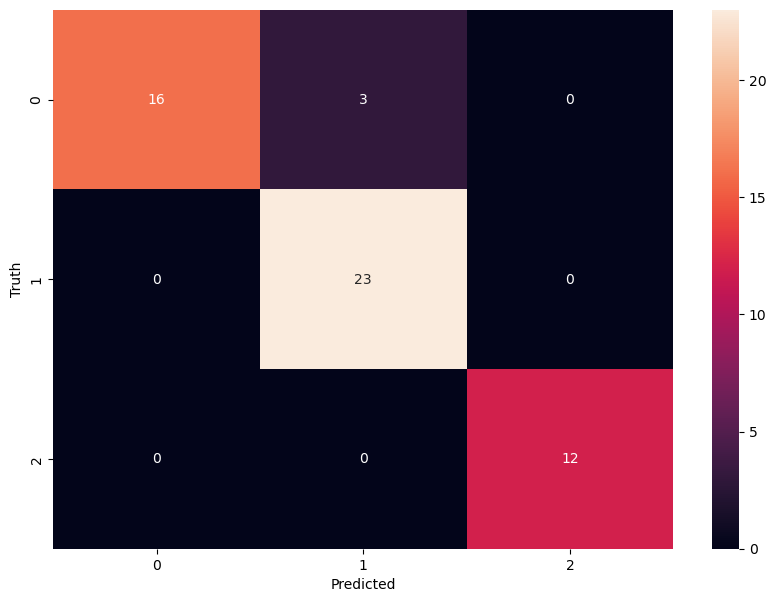

In [91]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')